In [17]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import pandas as pd
import os

DATA_DIR = "../data/processed"

df_path = os.path.join(DATA_DIR, "train_processed_advanced.csv")
df = pd.read_csv(df_path)

df.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
1,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
2,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,DoS
3,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
4,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal


In [19]:
#Split Features & Target
target_col = 'attack_class'

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (336715, 52)
y shape: (336715,)


In [20]:
#Encode Target Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [21]:
#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf.fit(X, y_encoded)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#Extract Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("Top Features:")
print(importance.head(10))

Top Features:
dst_host_srv_count             0.081197
total_bytes                    0.079066
src_bytes                      0.076430
log_src_bytes                  0.058794
dst_bytes                      0.049422
dst_host_same_src_port_rate    0.042588
root_shell                     0.041215
srv_count                      0.041039
serror_rate                    0.039067
src_bytes_ratio                0.038933
dtype: float64


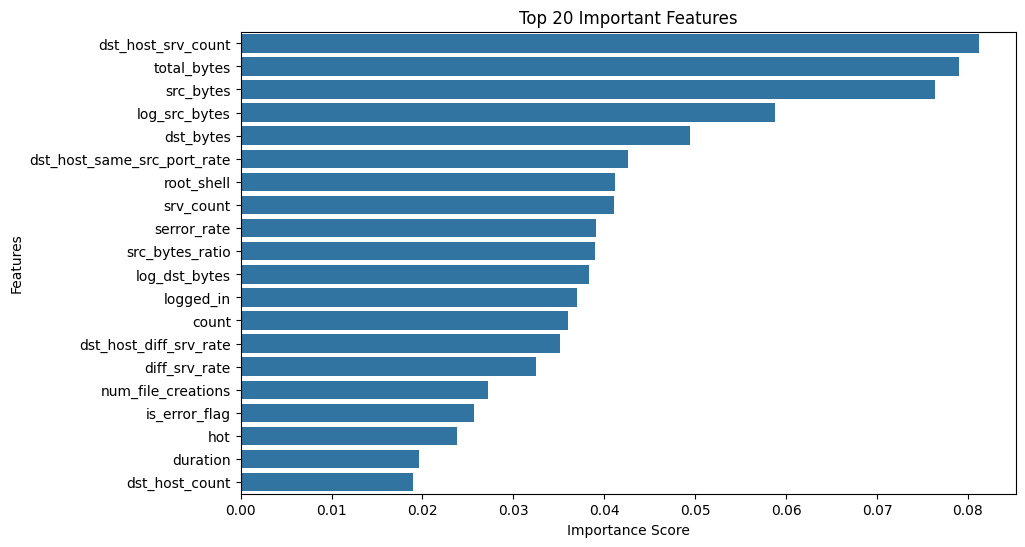

In [23]:
#Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=importance.head(20), y=importance.head(20).index)
plt.title("Top 20 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [24]:
#Set Threshold & Identify Low Features
threshold = 0.001

low_importance = importance[importance < threshold].index

print(f"Threshold value : {threshold}")
print(f"Total features  : {len(importance)}")
print(f"Low importance features (< {threshold}): {len(low_importance)}")

Threshold value : 0.001
Total features  : 52
Low importance features (< 0.001): 16


In [25]:
#Select Important Features
print("\nLow importance features:")
print(list(low_importance))


Low importance features:
['num_shells', 'flag_REJ', 'flag_SH', 'num_access_files', 'flag_RSTR', 'is_outlier', 'urgent', 'su_attempted', 'flag_S3', 'flag_S1', 'flag_RSTOS0', 'land', 'flag_S2', 'flag_OTH', 'is_host_login', 'num_outbound_cmds']


In [26]:
#Select Important Features
selected_features = importance[importance >= threshold].index.tolist()

print(f"\nFeatures kept (>= {threshold}) : {len(selected_features)}")
print(f"Features dropped (< {threshold}) : {len(low_importance)}")


Features kept (>= 0.001) : 36
Features dropped (< 0.001) : 16


In [27]:
#create new dataset
X_selected = X[selected_features]

print("Before:", X.shape)
print("After :", X_selected.shape)

Before: (336715, 52)
After : (336715, 36)


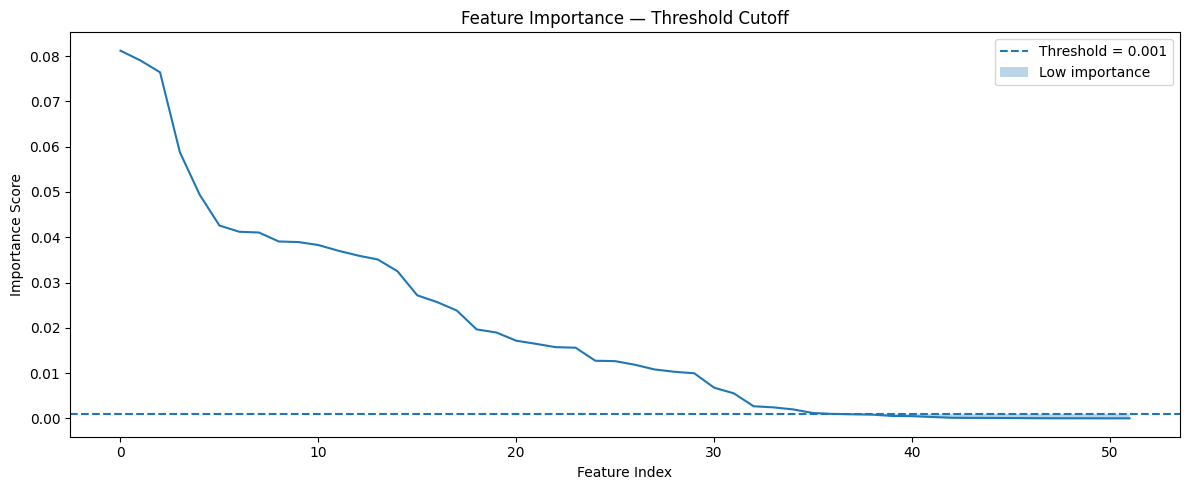

In [28]:
#plot threshold cut-off
plt.figure(figsize=(12, 5))

plt.plot(range(len(importance)), importance.values)

plt.axhline(y=threshold, linestyle='--', label=f'Threshold = {threshold}')

plt.fill_between(
    range(len(importance)),
    importance.values,
    threshold,
    where=importance.values < threshold,
    alpha=0.3,
    label='Low importance'
)

plt.title('Feature Importance — Threshold Cutoff')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
#Import TSNE and Take Random Sample
from sklearn.manifold import TSNE

sample_size = 3000

rows = np.random.choice(len(X), sample_size, replace=False)

X_sample = X.iloc[rows]
y_sample = y.iloc[rows]

In [32]:
#Apply TSNE
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

In [33]:
#Create dataframe
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'class': y_sample.values
})

tsne_df.head()

,TSNE1,TSNE2,class
0,-0.172532,19.232174,normal
1,-37.112701,18.191517,R2L
2,-9.488161,-10.440594,DoS
3,-51.662281,-28.651590,R2L
4,-11.244283,8.106392,Probe


In [34]:
#Define colours
unique_classes = tsne_df['class'].unique()

colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

color_map = dict(zip(unique_classes, colors))

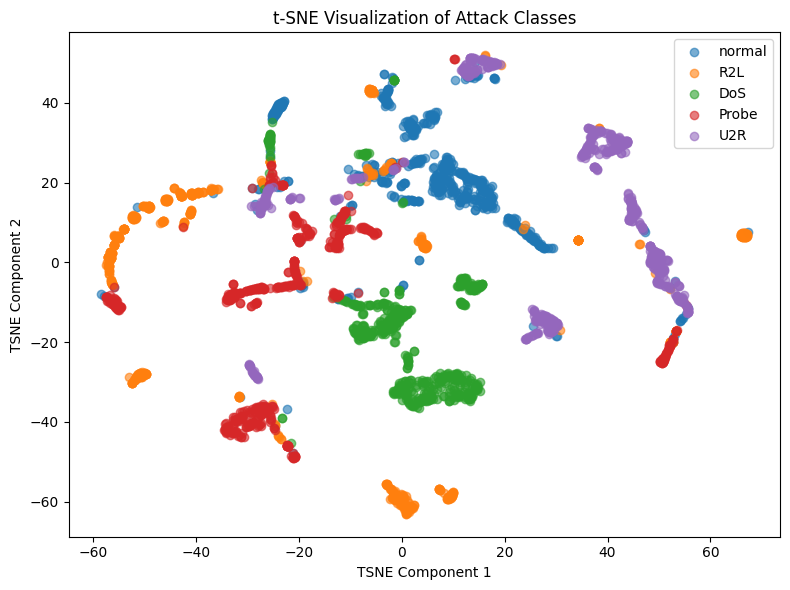

In [35]:
#Plot TSNE
plt.figure(figsize=(8,6))

for cls in unique_classes:
    subset = tsne_df[tsne_df['class'] == cls]
    
    plt.scatter(
        subset['TSNE1'],
        subset['TSNE2'],
        label=str(cls),
        alpha=0.6
    )

plt.title("t-SNE Visualization of Attack Classes")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend()
plt.tight_layout()
plt.show()